## 1.  LIBRERIAS

In [ ]:
pip install --pre --extra-index https://pypi.anaconda.org/scientific-python-nightly-wheels/simple scikit-learn

Looking in indexes: https://pypi.org/simple, https://pypi.anaconda.org/scientific-python-nightly-wheels/simple


In [ ]:
import pandas as pd
import numpy as np
import numpy.matlib

import matplotlib.colors

from sklearn.metrics import mean_squared_error as RMSE

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

#LIBRERIA PLS
from sklearn.cross_decomposition import PLSRegression

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import cross_val_predict
import matplotlib.ticker as ticker

## 2. FUNCIONES

In [ ]:
def wavelength_to_rgb(wavelength, gamma=0.8):
    ''' taken from http://www.noah.org/wiki/Wavelength_to_RGB_in_Python
    This converts a given wavelength of light to an
    approximate RGB color value. The wavelength must be given
    in nanometers in the range from 380 nm through 750 nm
    (789 THz through 400 THz).

    Based on code by Dan Bruton
    http://www.physics.sfasu.edu/astro/color/spectra.html
    Additionally alpha value set to 0.5 outside range
    '''
    wavelength = float(wavelength)
    if wavelength >= 380 and wavelength <= 750:
        A = 1.
    else:
        A=0.5
    if wavelength < 380:
        wavelength = 380.
    if wavelength >750:
        wavelength = 750.
    if wavelength >= 380 and wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif wavelength >= 440 and wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif wavelength >= 490 and wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif wavelength >= 510 and wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif wavelength >= 580 and wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif wavelength >= 645 and wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    return (R,G,B,A)


def print_wavelength(axs):
    end=920
    init=370
    clim=(init,end)
    norm = plt.Normalize(*clim)
    wl = np.arange(clim[0],clim[1]+1,1)
    colorlist = list(zip(norm(wl),[wavelength_to_rgb(w) for w in wl]))
    spectralmap = matplotlib.colors.LinearSegmentedColormap.from_list("spectrum", colorlist)

    #fig, axs = plt.subplots(figsize=(8,0.5))
    axs.get_yaxis().set_visible(False)
    #axs.get_xaxis().set_visible(False)
    #axs.YAxis.set_major_formatter(FormatStrFormatter('%.2f'))
    wavelengths = np.linspace(init, end, end-init+1)
    spectrum = np.ones(end-init+1)
    plt.plot(wavelengths, spectrum, color='darkred')

    y = np.linspace(0, 1, 100)
    X,Y = np.meshgrid(wavelengths, y)

    extent=(np.min(wavelengths), np.max(wavelengths), np.min(y), np.max(y))

    plt.imshow(X, clim=clim,  extent=extent, cmap=spectralmap, aspect='auto')
    plt.xlabel('Wavelength (nm)')




    plt.show()

    return

In [ ]:
def scatterplot(y_real, y_pred,ax):
    ax.scatter(y_real,y_pred)
    val_min=np.min([np.min(y_real.values.tolist()), np.min(y_pred)])
    val_max=np.min([np.max(y_real.values.tolist()), np.max(y_pred)])
    ax.set_title('REAL VS PREDICHO - DATA TRAIN')
    ax.plot([val_min, val_max], [val_min, val_max], ls="-", c="0.1")

    return

In [ ]:
def optimise_pls_cv(X, y, kfold, n_comp):
    # Define PLS object
    pls = PLSRegression(n_components=n_comp)

    # Cross-validation
    y_cv = cross_val_predict(pls, X, y,cv=kfold)
    pls.fit(X, y)

    #R2
    y_pred=pls.predict(X)

    # Calculate scores
    q2 = r2_score(y, y_cv)
    r2 = r2_score(y, y_pred)
    #RMSE=mean_squared_error(y, y_cv)**0.5

    return (r2,q2)

In [ ]:
def plot_metrics(vals, xticks, ylabel, objective,show):
    with plt.style.context('ggplot'):

        if objective=='min':
            idx = np.argmin(vals)
        else:
            idx = np.argmax(vals)

        if show:
          plt.plot(xticks, np.array(vals), '-v', color='blue', mfc='blue')
          plt.plot(xticks[idx], np.array(vals)[idx], 'P', ms=10, mfc='red')

          plt.xlabel('Number of PLS components')
          plt.xticks = xticks
          plt.ylabel(ylabel)
          plt.title('PLS')

        print("componente seleccionada: ",xticks[idx])
    return xticks[idx]

## 3. LECTURA DE DATOS

In [ ]:
data_df = pd.read_excel('BD harina, v2.xlsx')

In [ ]:
x = pd.DataFrame(data_df, columns=['DATA','B1','B2','B3','B4','B5','B6','B7','B8','B9','B10','B11','B12','B13','B14','B15','B16','B17','B18','B19','B20',
                                   'B21','B22','B23','B24','B25','B26','B27','B28','B29','B30','B31','B32','B33','B34','B35','B36','B37','B38','B39','B40',
                                   'B41','B42','B43','B44','B45','B46','B47','B48','B49','B50','B51','B52','B53','B54','B55','B56','B57','B58','B59','B60',
                                   'B61','B62','B63','B64','B65','B66','B67','B68','B69','B70','B71','B72','B73','B74','B75','B76','B77','B78','B79','B80',
                                   'B81','B82','B83','B84','B85','B86','B87','B88','B89','B90','B91','B92','B93','B94','B95','B96','B97','B98','B99','B100',
                                   'B101','B102','B103','B104','B105','B106','B107','B108','B109','B110','B111','B112','B113','B114','B115','B116','B117','B118','B119','B120',
                                   'B121','B122','B123','B124','B125','B126','B127','B128','B129','B130','B131','B132','B133','B134','B135','B136','B137','B138','B139','B140',
                                   'B141','B142','B143','B144','B145','B146','B147','B148','B149','B150','B151','B152','B153','B154','B155','B156','B157','B158','B159','B160',
                                   'B161','B162','B163','B164','B165','B166','B167','B168','B169','B170','B171','B172','B173','B174','B175','B176','B177','B178','B179','B180',
                                   'B181','B182','B183','B184','B185','B186','B187','B188','B189','B190','B191','B192','B193','B194','B195','B196','B197','B198','B199','B200',
                                   'B201','B202','B203','B204','B205','B206','B207','B208','B209','B210','B211','B212','B213','B214','B215','B216','B217','B218','B219','B220',
                                   'B221','B222','B223','B224','B225','B226','B227','B228','B229','B230','B231','B232','B233','B234','B235','B236','B237','B238','B239','B240'])

labels=[394.35,396.4374,398.5248,400.6122,402.6996,404.787,406.8744,408.9618,411.0492,413.1366,415.224,417.3114,419.3988,421.4862,423.5736,425.661,427.7484,429.8358,431.9232,434.0106,436.098,438.1854,440.2728,442.3602,444.4476,446.535,448.6224,450.7098,452.7972,454.8846,456.972,459.0594,461.1468,463.2342,465.3216,467.409,469.4964,471.5838,473.6712,475.7586,477.846,479.9334,482.0208,484.1082,486.1956,488.283,490.3704,492.4578,494.5452,496.6326,498.72,500.8074,502.8948,504.9822,507.0696,509.157,511.2444,513.3318,515.4192,517.5066,519.594,521.6814,523.7688,525.8562,527.9436,530.031,532.1184,534.2058,536.2932,538.3806,540.468,542.5554,544.6428,546.7302,548.8176,550.905,552.9924,555.0798,557.1672,559.2546,561.342,563.4294,565.5168,567.6042,569.6916,571.779,573.8664,575.9538,578.0412,580.1286,582.216,584.3034,586.3908,588.4782,590.5656,592.653,594.7404,596.8278,598.9152,601.0026,603.09,605.1774,607.2648,609.3522,611.4396,613.527,615.6144,617.7018,619.7892,621.8766,623.964,626.0514,628.1388,630.2262,632.3136,634.401,636.4884,638.5758,640.6632,642.7506,644.838,646.9254,649.0128,651.1002,653.1876,655.275,657.3624,659.4498,661.5372,663.6246,665.712,667.7994,669.8868,671.9742,674.0616,676.149,678.2364,680.3238,682.4112,684.4986,686.586,688.6734,690.7608,692.8482,694.9356,697.023,699.1104,701.1978,703.2852,705.3726,707.46,709.5474,711.6348,713.7222,715.8096,717.897,719.9844,722.0718,724.1592,726.2466,728.334,730.4214,732.5088,734.5962,736.6836,738.771,740.8584,742.9458,745.0332,747.1206,749.208,751.2954,753.3828,755.4702,757.5576,759.645,761.7324,763.8198,765.9072,767.9946,770.082,772.1694,774.2568,776.3442,778.4316,780.519,782.6064,784.6938,786.7812,788.8686,790.956,793.0434,795.1308,797.2182,799.3056,801.393,803.4804,805.5678,807.6552,809.7426,811.83,813.9174,816.0048,818.0922,820.1796,822.267,824.3544,826.4418,828.5292,830.6166,832.704,834.7914,836.8788,838.9662,841.0536,843.141,845.2284,847.3158,849.4032,851.4906,853.578,855.6654,857.7528,859.8402,861.9276,864.015,866.1024,868.1898,870.2772,872.3646,874.452,876.5394,878.6268,880.7142,882.8016,884.889,886.9764,889.0638,891.1512,893.2386]

y = pd.DataFrame(data_df, columns=['DATA','PROTEINA'])

In [ ]:
x_train=x[x['DATA'] =='TRAIN']
del x_train['DATA']

y_train=y[y['DATA'] =='TRAIN']
del y_train['DATA']

x_test=x[x['DATA'] =='TEST']
del x_test['DATA']

y_test=y[y['DATA'] =='TEST']
del y_test['DATA']

In [ ]:
len_x_train=np.size(x_train,0)
len_x_test=np.size(x_test,0)

print(len_x_train,len_x_test)

92 30


## 4. ANALISIS DESCRIPTIVO

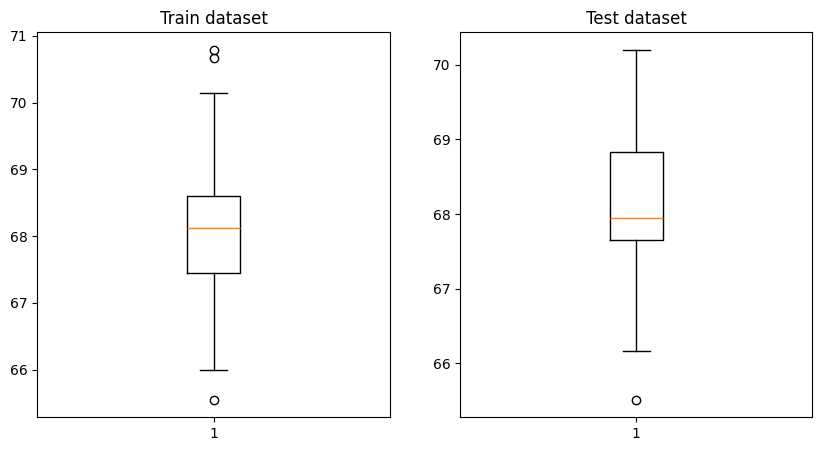

In [ ]:
fig = plt.figure(figsize =(10, 5))

ax1 = fig.add_subplot(1, 2, 1)
bp = plt.boxplot(y_train)
ax1.set_title("Train dataset")

ax3 = fig.add_subplot(1, 2, 2)
bp = plt.boxplot(y_test)
ax3.set_title("Test dataset")

plt.show()

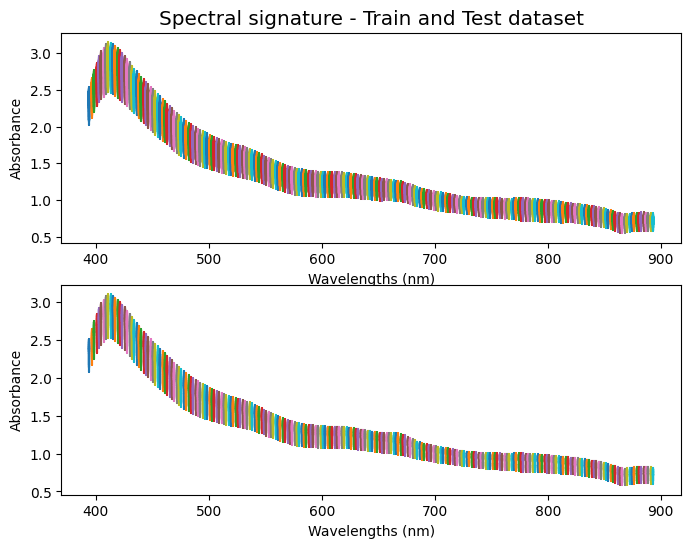

In [ ]:
#Ref_train = x_train
#Abs_train = (np.log10(1/Ref_train))

#Abs_train,ref = msc(np.array(x_train))
Abs_train = x_train

#Ref_test = x_test
#Abs_test = (np.log10(1/Ref_test))
#Abs_test = msc(np.array(x_test),ref)[0]
Abs_test = x_test


w1 =[394.35,396.4374,398.5248,400.6122,402.6996,404.787,406.8744,408.9618,411.0492,413.1366,415.224,417.3114,419.3988,421.4862,423.5736,425.661,427.7484,429.8358,431.9232,434.0106,436.098,438.1854,440.2728,442.3602,444.4476,446.535,448.6224,450.7098,452.7972,454.8846,456.972,459.0594,461.1468,463.2342,465.3216,467.409,469.4964,471.5838,473.6712,475.7586,477.846,479.9334,482.0208,484.1082,486.1956,488.283,490.3704,492.4578,494.5452,496.6326,498.72,500.8074,502.8948,504.9822,507.0696,509.157,511.2444,513.3318,515.4192,517.5066,519.594,521.6814,523.7688,525.8562,527.9436,530.031,532.1184,534.2058,536.2932,538.3806,540.468,542.5554,544.6428,546.7302,548.8176,550.905,552.9924,555.0798,557.1672,559.2546,561.342,563.4294,565.5168,567.6042,569.6916,571.779,573.8664,575.9538,578.0412,580.1286,582.216,584.3034,586.3908,588.4782,590.5656,592.653,594.7404,596.8278,598.9152,601.0026,603.09,605.1774,607.2648,609.3522,611.4396,613.527,615.6144,617.7018,619.7892,621.8766,623.964,626.0514,628.1388,630.2262,632.3136,634.401,636.4884,638.5758,640.6632,642.7506,644.838,646.9254,649.0128,651.1002,653.1876,655.275,657.3624,659.4498,661.5372,663.6246,665.712,667.7994,669.8868,671.9742,674.0616,676.149,678.2364,680.3238,682.4112,684.4986,686.586,688.6734,690.7608,692.8482,694.9356,697.023,699.1104,701.1978,703.2852,705.3726,707.46,709.5474,711.6348,713.7222,715.8096,717.897,719.9844,722.0718,724.1592,726.2466,728.334,730.4214,732.5088,734.5962,736.6836,738.771,740.8584,742.9458,745.0332,747.1206,749.208,751.2954,753.3828,755.4702,757.5576,759.645,761.7324,763.8198,765.9072,767.9946,770.082,772.1694,774.2568,776.3442,778.4316,780.519,782.6064,784.6938,786.7812,788.8686,790.956,793.0434,795.1308,797.2182,799.3056,801.393,803.4804,805.5678,807.6552,809.7426,811.83,813.9174,816.0048,818.0922,820.1796,822.267,824.3544,826.4418,828.5292,830.6166,832.704,834.7914,836.8788,838.9662,841.0536,843.141,845.2284,847.3158,849.4032,851.4906,853.578,855.6654,857.7528,859.8402,861.9276,864.015,866.1024,868.1898,870.2772,872.3646,874.452,876.5394,878.6268,880.7142,882.8016,884.889,886.9764,889.0638,891.1512,893.2386]
w2_train=np.matlib.repmat(w1,len_x_train,1)
w2_test=np.matlib.repmat(w1,len_x_test,1)

fig = plt.figure(figsize=(8, 6))

ax1 = fig.add_subplot(2, 1, 1)
with plt.style.context('ggplot'):
    plt.plot(w2_train, Abs_train, label='Absorbancia')
    plt.xlabel("Wavelengths (nm)")
    plt.ylabel("Absorbance")
    plt.title("Spectral signature - Train and Test dataset")

ax3 = fig.add_subplot(2, 1, 2)

with plt.style.context('ggplot'):
    plt.plot(w2_test, Abs_test, label='Absorbancia')
    plt.xlabel("Wavelengths (nm)")
    plt.ylabel("Absorbance")
    #plt.title("Firma Espectral-Data Test")



## 5. PREPROCESAMIENTO: Normalización de datos

In [ ]:
transformer = Normalizer().fit(Abs_train)

Abs_train = transformer.transform(Abs_train)
Abs_test = transformer.transform(Abs_test)

## 6. AJUSTE PLS: selección de número de componentes

In [ ]:
q2_ac = []
r2_ac = []
r2_s = []

variables=50
r2t=0
xticks= np.arange(1, variables+1)

for n_comp in xticks:
    r2, q2 = optimise_pls_cv(Abs_train, y_train, 10, n_comp)
    print("ajustando modelo a n componentes:",n_comp)


    r2_ac.append(r2)
    r2_s.append(r2-r2t)
    r2t=r2
    q2_ac.append(q2)


ajustando modelo a n componentes: 1
ajustando modelo a n componentes: 2
ajustando modelo a n componentes: 3
ajustando modelo a n componentes: 4
ajustando modelo a n componentes: 5
ajustando modelo a n componentes: 6
ajustando modelo a n componentes: 7
ajustando modelo a n componentes: 8
ajustando modelo a n componentes: 9
ajustando modelo a n componentes: 10
ajustando modelo a n componentes: 11
ajustando modelo a n componentes: 12
ajustando modelo a n componentes: 13
ajustando modelo a n componentes: 14
ajustando modelo a n componentes: 15
ajustando modelo a n componentes: 16
ajustando modelo a n componentes: 17
ajustando modelo a n componentes: 18
ajustando modelo a n componentes: 19
ajustando modelo a n componentes: 20
ajustando modelo a n componentes: 21
ajustando modelo a n componentes: 22
ajustando modelo a n componentes: 23
ajustando modelo a n componentes: 24
ajustando modelo a n componentes: 25
ajustando modelo a n componentes: 26
ajustando modelo a n componentes: 27
ajustando 

componente seleccionada:  50


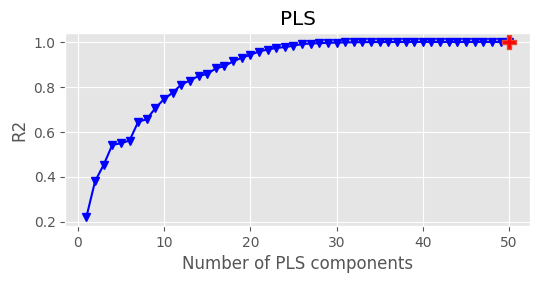

In [ ]:
fig = plt.figure(figsize =(6, 2.5))
NCOMP=plot_metrics(r2_ac, xticks,'R2', 'max',show=1)

componente seleccionada:  15


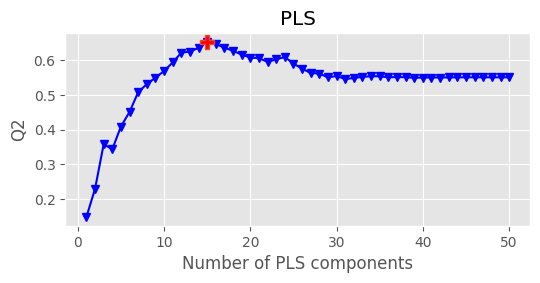

In [ ]:
fig = plt.figure(figsize =(6, 2.5))
NCOMP=plot_metrics(q2_ac, xticks,'Q2', 'max',show=1)

##7. VALIDACION

In [ ]:
NCOMP=15

pls = PLSRegression(n_components=NCOMP)
pls.fit(Abs_train, y_train)

#TRAIN AND TEST
y_pred_train=pls.predict(Abs_train, copy=True)
y_pred_test=pls.predict(Abs_test, copy=True)

r2 = r2_score(y_train, y_pred_train)*100
r2t = r2_score(y_test, y_pred_test)*100


print('R2-train:{0:.2f}%'.format(r2))
print('Q2:{0:.2f}%'.format(np.max(q2_ac)*100))
print('R2-test:{0:.2f}%'.format(r2t))

R2-train:85.76%
Q2:65.24%
R2-test:84.67%


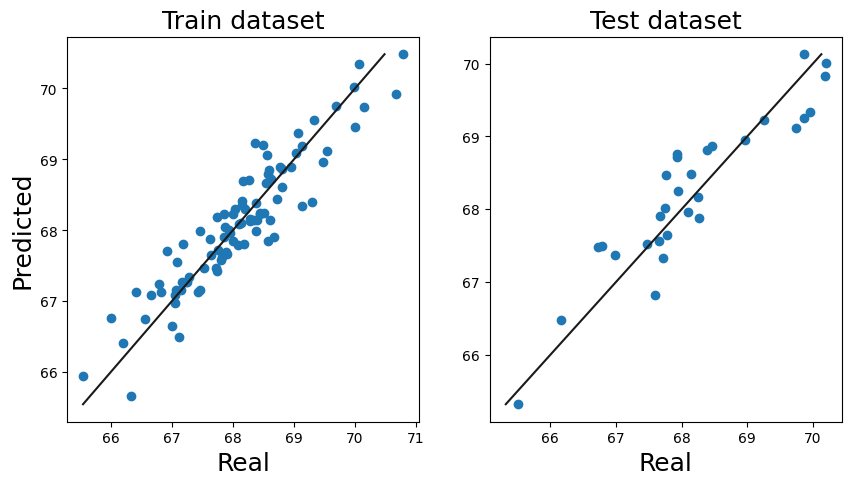

In [ ]:
fig = plt.figure(figsize =(10, 5))

ax1 = fig.add_subplot(1, 2, 1)
scatterplot(y_train,y_pred_train,ax1)
ax1.set_title("Train dataset",fontsize=18)
ax1.set_xlabel('Real',fontsize=18)
ax1.set_ylabel('Predicted',fontsize=18)

ax2 = fig.add_subplot(1, 2, 2)
scatterplot(y_test,y_pred_test,ax2)
ax2.set_title("Test dataset",fontsize=18)
ax2.set_xlabel('Real',fontsize=18)

plt.show()

fig.savefig('Fig 6.png', dpi=1200, bbox_inches = 'tight')

##8. BVE


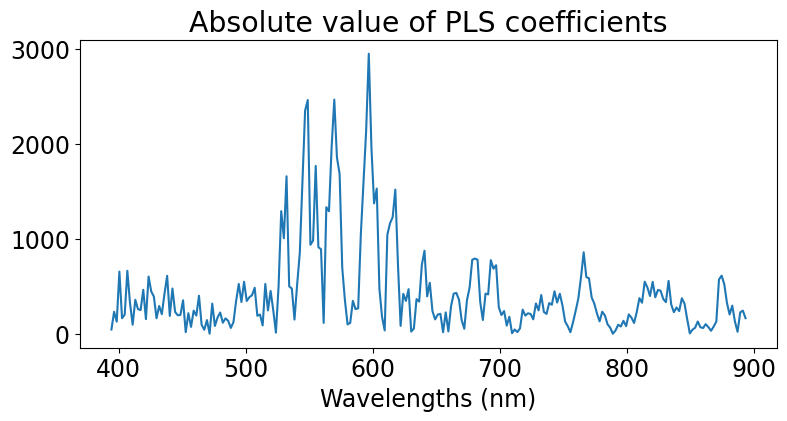

In [ ]:
plt.rcParams.update({'font.size': 17})

b=np.squeeze(np.abs(pls.coef_))

f,ax=plt.subplots(figsize=(9, 4))
ax.plot(labels,b)
ax.set_title('Absolute value of PLS coefficients')
ax.set_xlabel("Wavelengths (nm)")

plt.savefig('Fig 11.png', dpi=1200, bbox_inches = 'tight')

In [ ]:
#Initialization
idx_v_deleted=np.argmin(b)

R2_valid_record=[]
R2_train_record=[]
R2_test_record=[]
band_selected_record=[]

print('INITIALIZATION')
print('R2-train:{0:.2f}%'.format(r2))
print('R2-valid:{0:.2f}%'.format(np.max(q2_ac)*100))
print('R2-test:{0:.2f}%'.format(r2t))
print('------------------------------------------------------------------')
print('band candidate for elimination:{0:.2f}'.format(labels[idx_v_deleted]))

R2_valid_record.append(np.max(q2_ac)*100)
R2_train_record.append(r2)
R2_test_record.append(r2t)
band_selected_record.append(labels[idx_v_deleted])

INITIALIZATION
R2-train:85.76%
R2-valid:65.24%
R2-test:84.67%
------------------------------------------------------------------
band candidate for elimination:788.87


In [34]:
#removing selected band
STEPS=200
Abs_train_copy=Abs_train
Abs_test_copy=Abs_test
labels_copy=labels

for i in range(STEPS):
  Abs_train_copy=np.delete(Abs_train_copy, idx_v_deleted, axis=1)
  Abs_test_copy=np.delete(Abs_test_copy, idx_v_deleted, axis=1)
  labels_copy=np.delete(labels_copy, idx_v_deleted)

  q2_ac = []
  r2_ac = []
  r2_s = []

  #variables=50
  variables=np.min([50, np.size(Abs_train_copy,1)])

  r2t=0
  xticks= np.arange(1, variables+1)

  for n_comp in xticks:
      r2, q2 = optimise_pls_cv(Abs_train_copy, y_train, 10, n_comp)
      r2_ac.append(r2)
      r2_s.append(r2-r2t)
      r2t=r2
      q2_ac.append(q2)

  print('STEP:{0:.0f}'.format(i+1))
  NCOMP=plot_metrics(q2_ac, xticks,'Q2', 'max',show=0)
  pls = PLSRegression(n_components=NCOMP)
  pls.fit(Abs_train_copy, y_train)

  #COEFFICIENTS
  b=np.squeeze(np.abs(pls.coef_))
  idx_v_deleted=np.argmin(b)

  #TRAIN AND TEST
  y_pred_train=pls.predict(Abs_train_copy, copy=True)
  y_pred_test=pls.predict(Abs_test_copy, copy=True)
  r2 = r2_score(y_train, y_pred_train)*100
  r2t = r2_score(y_test, y_pred_test)*100

  #RECORD
  R2_valid_record.append(np.max(q2_ac)*100)
  R2_train_record.append(r2)
  R2_test_record.append(r2t)
  band_selected_record.append(labels_copy[idx_v_deleted])



  print('number of bands:{0:.0f}'.format(np.size(Abs_train_copy,1)))
  print('R2-train:{0:.2f}%'.format(r2))
  print('R2-valid:{0:.2f}%'.format(np.max(q2_ac)*100))
  print('R2-test:{0:.2f}%'.format(r2t))

  print('band candidate for elimination:{0:.2f}'.format(labels_copy[idx_v_deleted]))

  print('------------------------------------------------------------------')

STEP:1
componente seleccionada:  15
number of bands:239
R2-train:85.76%
R2-valid:65.25%
R2-test:84.70%
band candidate for elimination:471.58
------------------------------------------------------------------
STEP:2
componente seleccionada:  15
number of bands:238
R2-train:85.78%
R2-valid:65.39%
R2-test:84.69%
band candidate for elimination:849.40
------------------------------------------------------------------
STEP:3
componente seleccionada:  15
number of bands:237
R2-train:85.78%
R2-valid:65.37%
R2-test:84.70%
band candidate for elimination:709.55
------------------------------------------------------------------
STEP:4
componente seleccionada:  15
number of bands:236
R2-train:85.78%
R2-valid:65.40%
R2-test:84.70%
band candidate for elimination:523.77
------------------------------------------------------------------
STEP:5
componente seleccionada:  15
number of bands:235
R2-train:85.81%
R2-valid:65.56%
R2-test:84.68%
band candidate for elimination:755.47
---------------------------

R2-train:86.01%
R2-valid:76.25%
R2-test:86.68%


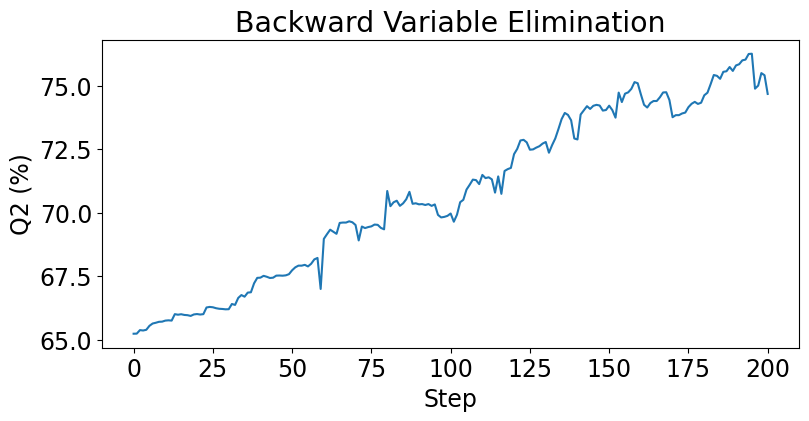

In [35]:
#R2_valid_record
#R2_train_record
#R2_test_record


objetive=R2_valid_record
plt.rcParams.update({'font.size': 17})

STEPS=200
f,ax=plt.subplots(figsize=(9, 4))

ax.plot(np.arange(0,STEPS+1),objetive)
ax.set_title('Backward Variable Elimination')
ax.set_xlabel('Step')
ax.set_ylabel('Q2 (%)')
ax.xaxis.set_major_locator(ticker.MultipleLocator(25))
ax.xaxis.set_tick_params(rotation=0)
ax.yaxis.set_tick_params(rotation=0)

idx=np.argmax(objetive)


plt.savefig('Fig 12.png', dpi=1200, bbox_inches = 'tight')

print('R2-train:{0:.2f}%'.format(R2_train_record[idx]))
print('R2-valid:{0:.2f}%'.format(R2_valid_record[idx]))
print('R2-test:{0:.2f}%'.format(R2_test_record[idx]))



In [36]:
# Calculate prediction errors
train_errors = y_train.values.flatten() - y_pred_train.flatten()
test_errors = y_test.values.flatten() - y_pred_test.flatten()

# Create a DataFrame for the errors
errors_df = pd.DataFrame({'Error': np.concatenate([train_errors, test_errors]),
                         'Dataset': ['Train'] * len(train_errors) + ['Test'] * len(test_errors)})
print(errors_df)
# Save the DataFrame to an Excel file
errors_df.to_excel('train_test_errors.xlsx', index=False)

        Error Dataset
0    0.306265   Train
1    0.001555   Train
2   -0.165542   Train
3   -0.357503   Train
4   -0.265400   Train
..        ...     ...
117 -0.166429    Test
118 -0.448763    Test
119  0.077215    Test
120 -0.036957    Test
121 -0.415367    Test

[122 rows x 2 columns]


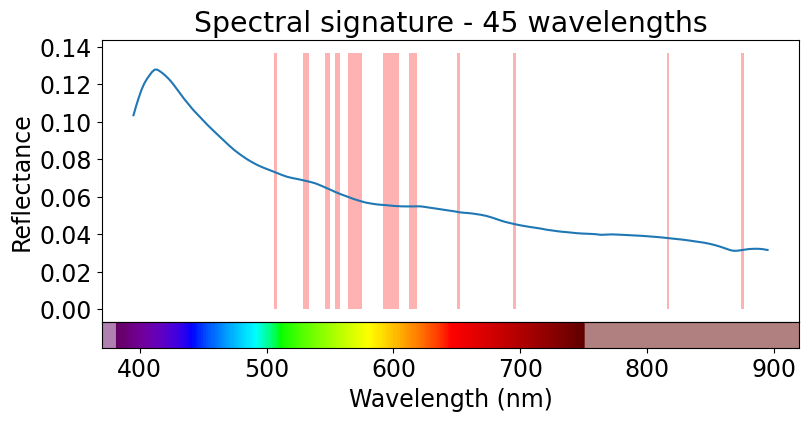

In [37]:
band_deleted=band_selected_record[0:idx]

deleted = np.in1d(labels, band_deleted)

margin=0.005
fig, ax = plt.subplots(2, figsize=(9,4), height_ratios=[11, 1])
plt.subplots_adjust(wspace=0, hspace=0)

ax[0].plot(w1, np.mean(Abs_train,0))
ax[0].set_title("Spectral signature - {0:.0f} wavelengths".format(240-np.size(band_deleted)))
ax[0].get_yaxis().set_visible(True)
ax[0].get_xaxis().set_visible(False)
ax[0].yaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax[0].set_ylabel("Reflectance")

ax[0].fill_between(w1,np.max(Abs_train)+margin, where=deleted==False, facecolor='red', alpha=0.3)


print_wavelength(ax[1])



fig.savefig('Fig 13.png', dpi=1200, bbox_inches = 'tight')

In [41]:
Abs_train_copy=Abs_train[:,(deleted==False)]
Abs_test_copy=Abs_test[:,(deleted==False)]

NCOMP=12

pls = PLSRegression(n_components=NCOMP)
pls.fit(Abs_train_copy, y_train)

y_pred_train=pls.predict(Abs_train_copy, copy=True)
y_pred_test=pls.predict(Abs_test_copy, copy=True)

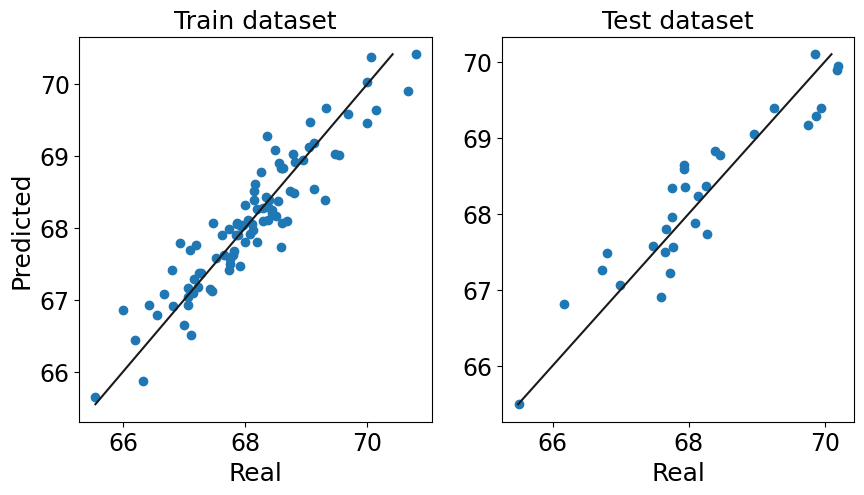

In [42]:
fig = plt.figure(figsize =(10, 5))

ax1 = fig.add_subplot(1, 2, 1)
scatterplot(y_train,y_pred_train,ax1)
ax1.set_title("Train dataset",fontsize=18)
ax1.set_xlabel('Real',fontsize=18)
ax1.set_ylabel('Predicted',fontsize=18)

ax2 = fig.add_subplot(1, 2, 2)
scatterplot(y_test,y_pred_test,ax2)
ax2.set_title("Test dataset",fontsize=18)
ax2.set_xlabel('Real',fontsize=18)

plt.show()

fig.savefig('Fig 14.png', dpi=1200, bbox_inches = 'tight')

In [43]:
print("RMSE train",RMSE(y_train,y_pred_train))
print("RMSE test",RMSE(y_test,y_pred_test))


record = y_test.assign(Predicted=y_pred_test)

record.to_excel('record-PLS-BVE.xlsx', index=False)

RMSE train 0.1394832753130242
RMSE test 0.17847793532456474
